🟢 Todas as features
melhor performance
interpretação direta
baseline
🔵 PCA
redução de dimensionalidade
estabilidade
combate multicolinearidade
🟣 seleção de features (LASSO)
interpretabilidade forte
mantém variáveis reais

https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset

ClustOfVar is a software package (an R package) designed specifically for clustering variables — grouping a set of variables into clusters such that variables in the same cluster share similar information — rather than clustering observations/records. 

What It Is
Category: Software — R package for clustering variables.

Name: ClustOfVar

Language: R (statistical programming language).

Purpose: To perform clustering of variables (quantitative, qualitative, or mixed types) based on how strongly they relate. 

Key Features
Clusters variables, not observations: Instead of grouping data points, it groups columns/variables that carry similar information. 

Works with mixed variable types: Handles quantitative, qualitative, or mixtures of both. 

Cluster Center: Each cluster is represented by a synthetic variable — typically the first principal component from PCAMIX (a method that combines PCA and multiple correspondence analysis) — summarizing the members. 

Clustering Algorithms Provided:

Hierarchical clustering of variables (hclustvar)

K-means-type clustering of variables (kmeansvar)
Both aim to maximize a homogeneity criterion based on correlations between variables and cluster centers. 

Bootstrapping support: Can estimate the stability of variable clusters and help select the number of clusters. 

Use Cases
Dimension reduction: By grouping similar variables, you can reduce dimensionality or construct representative features. 

Variable selection/pre-processing: Useful prior to modelling to identify related groups of features. 

Mixed data scenarios: Particularly helpful when datasets include both categorical and numerical variables. 

Functions You’ll See
Some functions in the package include (but are not limited to):

hclustvar() – hierarchical clustering of variables

kmeansvar() – k-means style clustering of variables

cutreevar() – cut a hierarchical tree into a fixed number of clusters

stability() – assess clustering stability

Plot and summary methods for clusters and dendrograms 

podemos encaixar 

In [6]:
library(tidyverse)
library("tidymodels")
library('janitor')
library('ggcorrplot')
library(workflowsets)
library(rstanarm)
library(glmnet)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
── Attaching packages ────────────────────────────────────── tidymodels 1.5.0 ──

✔ broom        1.0.12     ✔ rsample      1.3.2 
✔ dials        1.4.3      ✔ tailor       0.1.0 
✔ infer        1.1.0      ✔ tune         2.1.0 
✔ modeldata    1.5.1      ✔ workflows    1.3.0 
✔ parsnip      1.5.0      ✔ workflowsets 1.1.1 
✔ recipes      1.3.2      ✔ yardstick    1.4.0 

── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ scales::discard() mask

In [9]:
cancer <- read_csv("C:\\Users\\T-GAMER\\OneDrive\\Documentos\\GitHub\\monografia-ufmg\\data\\default\\UCI_Credit_Card.csv")

Rows: 30000 Columns: 25
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (25): ID, LIMIT_BAL, SEX, EDUCATION, MARRIAGE, AGE, PAY_0, PAY_2, PAY_3,...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [10]:
cancer <- cancer %>%
  rename(
    id_cliente = ID,
    limite_credito = LIMIT_BAL,
    sexo = SEX,
    escolaridade = EDUCATION,
    estado_civil = MARRIAGE,
    idade = AGE,
    atraso_pagamento_0 = PAY_0,
    atraso_pagamento_2 = PAY_2,
    atraso_pagamento_3 = PAY_3,
    atraso_pagamento_4 = PAY_4,
    atraso_pagamento_5 = PAY_5,
    atraso_pagamento_6 = PAY_6,
    fatura_valor_1 = BILL_AMT1,
    fatura_valor_2 = BILL_AMT2,
    fatura_valor_3 = BILL_AMT3,
    fatura_valor_4 = BILL_AMT4,
    fatura_valor_5 = BILL_AMT5,
    fatura_valor_6 = BILL_AMT6,
    pagamento_valor_1 = PAY_AMT1,
    pagamento_valor_2 = PAY_AMT2,
    pagamento_valor_3 = PAY_AMT3,
    pagamento_valor_4 = PAY_AMT4,
    pagamento_valor_5 = PAY_AMT5,
    pagamento_valor_6 = PAY_AMT6,
    inadimplencia_proximo_mes = default.payment.next.month
  )

In [11]:
cancer

id_cliente,limite_credito,sexo,escolaridade,estado_civil,idade,atraso_pagamento_0,atraso_pagamento_2,atraso_pagamento_3,atraso_pagamento_4,⋯,fatura_valor_4,fatura_valor_5,fatura_valor_6,pagamento_valor_1,pagamento_valor_2,pagamento_valor_3,pagamento_valor_4,pagamento_valor_5,pagamento_valor_6,inadimplencia_proximo_mes
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,20000,2,2,1,24,2,2,-1,-1,⋯,0,0,0,0,689,0,0,0,0,1
2,120000,2,2,2,26,-1,2,0,0,⋯,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,90000,2,2,2,34,0,0,0,0,⋯,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,50000,2,2,1,37,0,0,0,0,⋯,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
5,50000,1,2,1,57,-1,0,-1,0,⋯,20940,19146,19131,2000,36681,10000,9000,689,679,0
6,50000,1,1,2,37,0,0,0,0,⋯,19394,19619,20024,2500,1815,657,1000,1000,800,0
7,500000,1,1,2,29,0,0,0,0,⋯,542653,483003,473944,55000,40000,38000,20239,13750,13770,0
8,100000,2,2,2,23,0,-1,-1,0,⋯,221,-159,567,380,601,0,581,1687,1542,0
9,140000,2,3,1,28,0,0,2,0,⋯,12211,11793,3719,3329,0,432,1000,1000,1000,0


In [4]:
n_obs <- nrow(cancer)
n_vars <- ncol(cancer)

In [ ]:
```{python py-describe-dataset, echo=FALSE}
#| label: tbl-variaveis-num
#| tbl-cap: "Estatísticas descritivas das variáveis numéricas do conjunto de dados."
loan.columns = loan.columns.str.strip()
cols = loan.columns.drop("loan_id")
resumo = loan[cols].describe().T[["mean", "50%", "min", "max", 'std']]
resumo = resumo.rename(columns={"50%": "median"}).round(2)

Markdown(tabulate(resumo, headers = resumo.columns))
#loan[cols].describe()
```

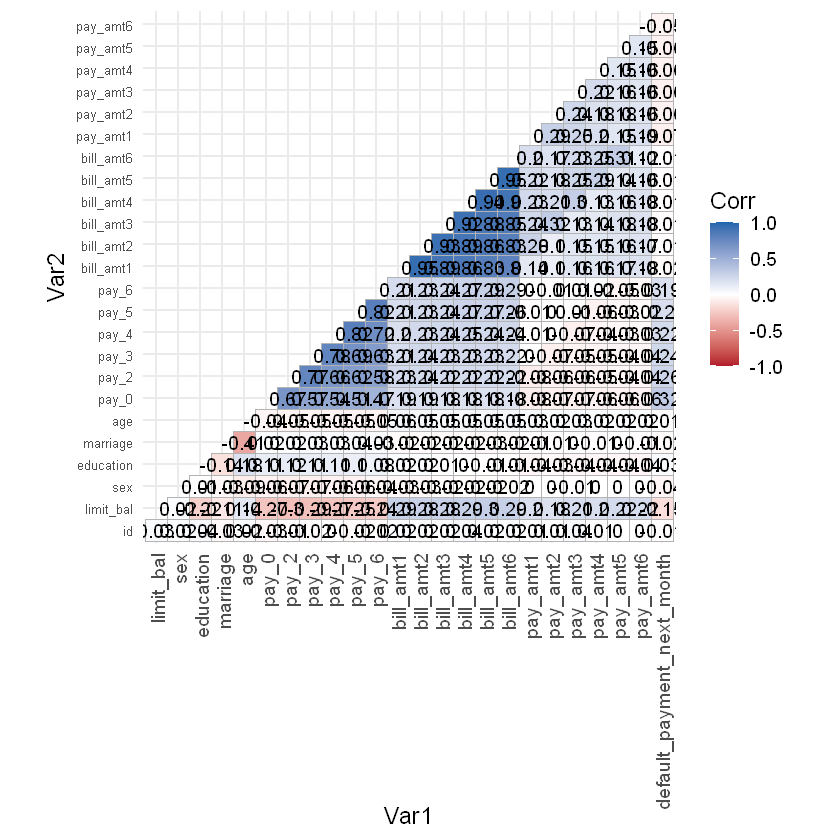

In [172]:
cancer_num <- cancer |>
  dplyr::select(where(is.numeric))

cor_matrix <- cor(
  cancer_num,
  use = "complete.obs",
  method = "pearson"
)

ggcorrplot(
  cor_matrix,
  type = "lower",
  lab = TRUE,
  lab_size = 4,
  colors = c("#b2182b", "white", "#2166ac"),
  outline.col = "gray70"
) +
  theme_minimal(base_size = 14) +
  theme(
    axis.text.x = element_text(
      angle = 90,
      hjust = 1,
      vjust = 0.5
    ),
    axis.text.y = element_text(size = 8)
  )

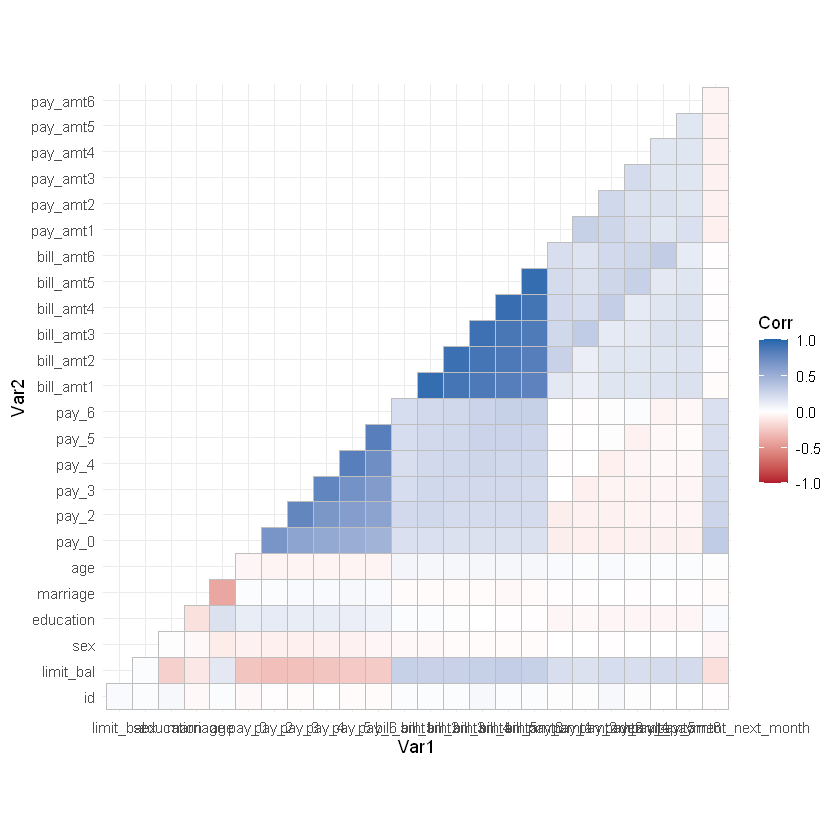

In [173]:
ggcorrplot(
  cor_matrix,
  type = "lower",
  lab = FALSE,   # <- ESSENCIAL
  colors = c("#b2182b", "white", "#2166ac")
) +
  theme_minimal()

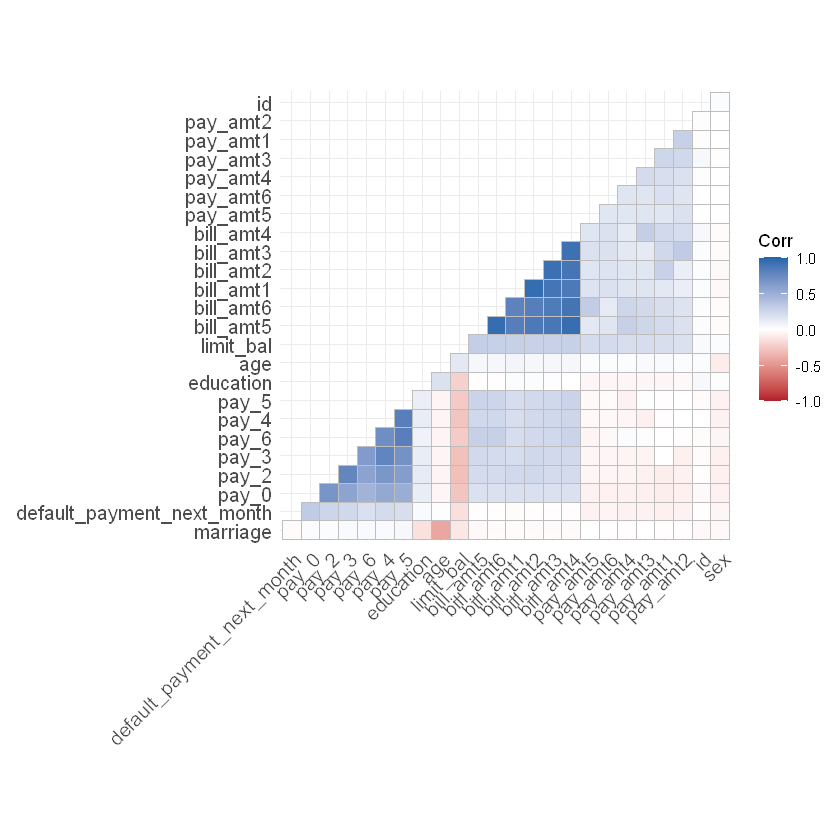

In [174]:
ggcorrplot(
  cor_matrix,
  type = "lower",
  lab = FALSE,
  hc.order = TRUE,   # 🔥 reorganiza por similaridade
  colors = c("#b2182b", "white", "#2166ac")
)

In [175]:
install.packages("corrplot")

Warning message:
"o pacote 'corrplot' está em uso e não será instalado"


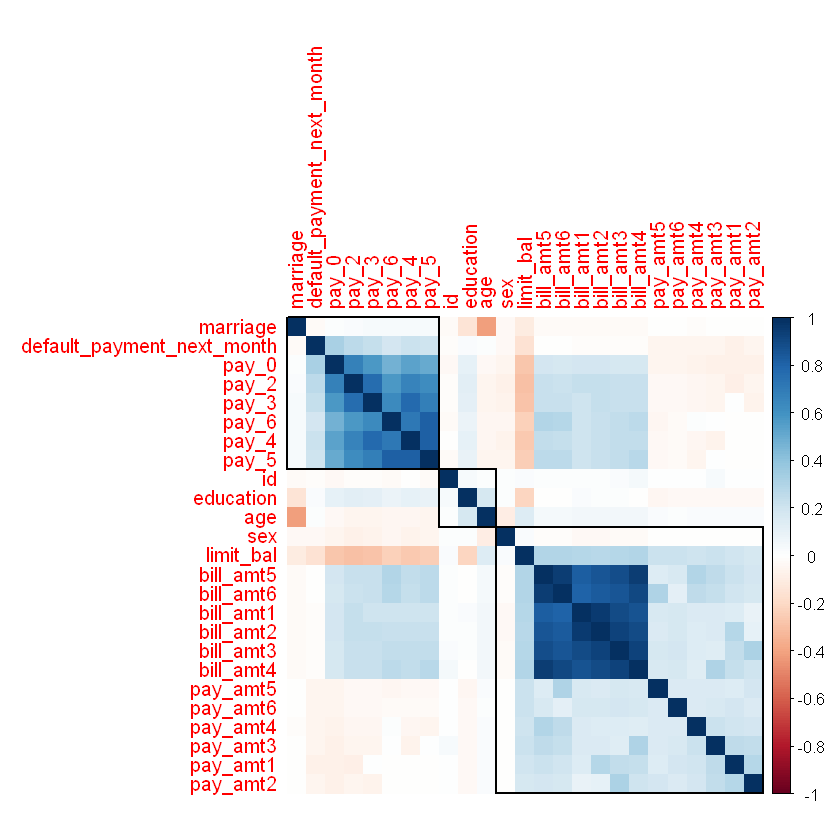

In [176]:
library(corrplot)

corrplot(
  cor_matrix,
  method = "color",
  order = "hclust",
  addrect = 3
)

In [177]:
cancer_num <- cancer |> dplyr::select(where(is.numeric))

cor_matrix <- cor(cancer_num, use = "complete.obs")

In [178]:
library(caret)

high_corr <- findCorrelation(cor_matrix, cutoff = 0.7)

cancer_reduced <- cancer_num[, -high_corr]

In [179]:
library(tidyverse)
library("tidymodels")
library('janitor')
library('ggcorrplot')
library(workflowsets)
library(rstanarm)
library(glmnet)

In [180]:
cancer$default_payment_next_month <- as.factor(cancer$default_payment_next_month)

In [181]:
split <- initial_split(
  cancer,
  prop   = 0.75,
  strata = default_payment_next_month
)

train_data <- training(split)
test_data  <- testing(split)

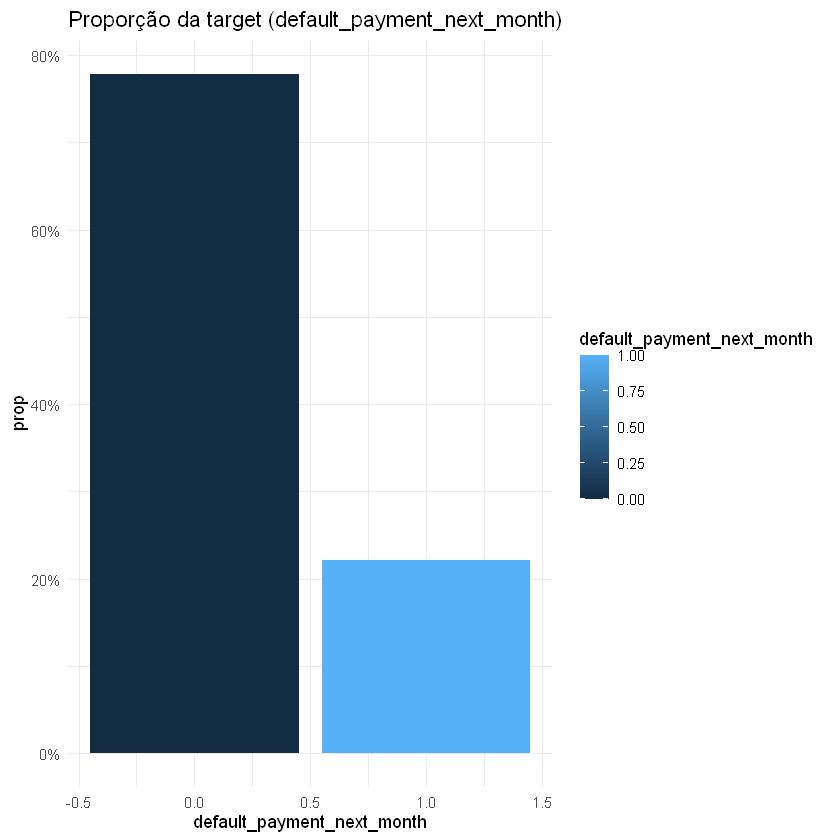

In [182]:
cancer_reduced |>
  dplyr::count(default_payment_next_month) |>
  dplyr::mutate(prop = n / sum(n)) |>
  ggplot(aes(x = default_payment_next_month, y = prop, fill = default_payment_next_month)) +
  geom_col() +
  scale_y_continuous(labels = scales::percent) +
  theme_minimal() +
  labs(title = "Proporção da target (default_payment_next_month)")

In [184]:
library(dplyr)

train_data |>
  count(default_payment_next_month) |>
  mutate(prop = n / sum(n),
         dataset = "treino")

test_data |>
  count(default_payment_next_month) |>
  mutate(prop = n / sum(n),
         dataset = "teste")

default_payment_next_month,n,prop,dataset
<fct>,<int>,<dbl>,<chr>
0,17523,0.7788,treino
1,4977,0.2212,treino


default_payment_next_month,n,prop,dataset
<fct>,<int>,<dbl>,<chr>
0,5841,0.7788,teste
1,1659,0.2212,teste


In [212]:
log_glm <- logistic_reg() |>
  set_engine("glm") |>
  set_mode("classification")
#lasso
log_l1 <- logistic_reg(
  penalty = tune(),
  mixture = 1
) |>
  set_engine("glmnet") |>
  set_mode("classification")

In [ ]:
#modelo geral
rec_all <- recipe(default_payment_next_month ~ ., data = train_data) %>%
  step_dummy(all_nominal_predictors()) %>%
  step_normalize(all_numeric_predictors())

rec_l1 <- recipe(
  default_payment_next_month ~ .,
  data = train_data
) |>
  step_normalize(all_numeric_predictors())
#rodar L1



# Removendo alta correlação
rec_corr <- recipe(
  default_payment_next_month ~ .,
  data = train_data
) |>
  step_corr(all_numeric_predictors(), threshold = 0.7)


#com pca
rec_pca <- recipe(
  default_payment_next_month ~ .,
  data = train_data
) |>
  step_normalize(all_numeric_predictors()) |>
  step_pca(all_numeric_predictors(), threshold = 0.95)

In [214]:
wf_all <- workflow() |>
  add_recipe(rec_all) |>
  add_model(log_glm)
wf_corr <- workflow() |>
  add_recipe(rec_corr) |>
  add_model(log_glm)
wf_pca <- workflow() |>
  add_recipe(rec_pca) |>
  add_model(log_glm)
wf_l1 <- workflow() |>
  add_recipe(rec_all) |>
  add_model(log_l1)

In [217]:
library(tidymodels)

set.seed(123)

folds <- vfold_cv(train_data, v = 5, strata = default_payment_next_month)
grid <- grid_regular(
  penalty(range = c(-4, 0)),  # 1e-4 até 1
  levels = 20
)

In [218]:
metrics <- metric_set(
  accuracy,
  roc_auc,
  f_meas
)

In [219]:
tuned_l1 <- tune_grid(
  wf_l1,
  resamples = folds,
  grid = grid,
  metrics = metrics
)

In [220]:
best_l1 <- select_best(tuned_l1, metric = "roc_auc")
best_l1

penalty,.config
<dbl>,<chr>
0.0001623777,pre0_mod02_post0


In [221]:
final_l1 <- finalize_workflow(wf_l1, best_l1)
final_fit <- fit(final_l1, train_data)

In [228]:
library(broom)

coef_table <- extract_fit_engine(final_fit) |>
  coef(s = best_l1$penalty)
  coef_table

25 x 1 sparse Matrix of class "dgCMatrix"
            s=0.0001623777
(Intercept)    -1.46765645
id             -0.01091255
limit_bal      -0.11937263
sex            -0.05681880
education      -0.07351083
marriage       -0.08392422
age             0.07594876
pay_0           0.65849456
pay_2           0.08923067
pay_3           0.07439333
pay_4           0.03312879
pay_5           0.03990051
pay_6           .         
bill_amt1      -0.32068321
bill_amt2       0.07329591
bill_amt3       0.09387813
bill_amt4       .         
bill_amt5       .         
bill_amt6       0.07105718
pay_amt1       -0.21263135
pay_amt2       -0.22072544
pay_amt3       -0.06867355
pay_amt4       -0.05088303
pay_amt5       -0.04583969
pay_amt6       -0.04239873

In [223]:
models <- list(
  all = wf_all,
  corr = wf_corr,
  pca = wf_pca
  #l1 = wf_l1
)

fits <- purrr::map(models, ~fit(.x, train_data))

Warning message:
"glm.fit: probabilidades ajustadas numericamente 0 ou 1 ocorreu"


In [230]:
final_l1 <- finalize_workflow(wf_l1, best_l1)
fit_l1 <- fit(final_l1, train_data)

In [231]:
fits_all <- c(
  fits,
  l1 = list(fit_l1)
)

In [232]:
library(yardstick)
library(dplyr)
library(purrr)

preds <- purrr::imap_dfr(fits_all, function(model, name) {

  test_pred <- predict(model, test_data, type = "prob")
  class_pred <- predict(model, test_data, type = "class")

  tibble(
    wflow_id = name,
    truth = test_data$default_payment_next_month,
    class = class_pred$.pred_class,
    prob = test_pred[[2]]   # classe positiva
  )
})

In [233]:
metrics_table <- preds %>%
  group_by(wflow_id) %>%
  summarise(

    # 📌 classificação geral
    accuracy = accuracy_vec(truth, class),
    bal_accuracy = bal_accuracy_vec(truth, class),

    # 📌 ranking / separação
    roc_auc = roc_auc_vec(truth, prob, event_level = "second"),
    log_loss = mn_log_loss_vec(truth, prob),

    # 📌 sensibilidade / especificidade
    sens = sens_vec(truth, class),
    spec = spec_vec(truth, class),

    # 📌 custo de erro (crédito)
    precision = precision_vec(truth, class),
    npv = npv_vec(truth, class),

    # 📌 equilíbrio
    f1 = f_meas_vec(truth, class),
    f2 = f_meas_vec(truth, class, beta = 2),

    # 📌 robustez estatística
    kap = kap_vec(truth, class),
    mcc = mcc_vec(truth, class),

    # 📌 equilíbrio sens/spec
    gmean = sqrt(sens_vec(truth, class) * spec_vec(truth, class)),

    .groups = "drop"
  )

In [234]:
metrics_table

wflow_id,accuracy,bal_accuracy,roc_auc,log_loss,sens,spec,precision,npv,f1,f2,kap,mcc,gmean
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
all,0.8134667,0.6107281,0.7210339,1.561720,0.9743195,0.2471368,0.8200288,0.7321429,0.8905406,0.9389850,0.2903002,0.3496883,0.4907038
corr,0.8116000,0.6073719,0.7181833,1.554363,0.9736347,0.2411091,0.8187446,0.7220217,0.8894971,0.9381392,0.2819795,0.3407729,0.4845123
l1,0.8133333,0.6102110,0.7205684,1.557836,0.9744907,0.2459313,0.8198185,0.7324955,0.8904881,0.9390570,0.2891897,0.3489157,0.4895485
pca,0.8112000,0.6062519,0.7172414,1.551693,0.9738059,0.2386980,0.8182995,0.7213115,0.8893058,0.9381494,0.2794342,0.3386287,0.4821260


In [241]:
fits_tbl <- tibble(
  wflow_id = names(fits_all),
  fit = fits_all
)

In [242]:
extract_model_summary <- function(wf_fit) {
  model_fit <- workflows::extract_fit_parsnip(wf_fit)

  if (inherits(model_fit$fit, "glm")) {
    return(summary(model_fit$fit))
  }

  if (inherits(model_fit$fit, "lognet")) {
    return(model_fit$fit)
  }

  NULL
}

In [245]:
model_summaries <- fits_tbl %>%
  mutate(
    summary = purrr::map(fit, extract_model_summary)
  ) %>%
  select(wflow_id, summary)
for (i in seq_len(nrow(model_summaries)-1)) {
  cat("\n==============================\n")
  cat("Modelo:", model_summaries$wflow_id[i], "\n")
  cat("==============================\n\n")
  print(model_summaries$summary[[i]])
}


Modelo: all 


Call:
stats::glm(formula = ..y ~ ., family = stats::binomial, data = data)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept) -1.4713481  0.0193053 -76.215  < 2e-16 ***
id          -0.0124313  0.0175348  -0.709 0.478356    
limit_bal   -0.1190963  0.0236274  -5.041 4.64e-07 ***
sex         -0.0582483  0.0173247  -3.362 0.000773 ***
education   -0.0758751  0.0192177  -3.948 7.87e-05 ***
marriage    -0.0854797  0.0191586  -4.462 8.13e-06 ***
age          0.0769321  0.0189306   4.064 4.83e-05 ***
pay_0        0.6578971  0.0229865  28.621  < 2e-16 ***
pay_2        0.0908237  0.0278455   3.262 0.001107 ** 
pay_3        0.0721843  0.0313016   2.306 0.021106 *  
pay_4        0.0330720  0.0339201   0.975 0.329562    
pay_5        0.0402486  0.0354172   1.136 0.255785    
pay_6       -0.0002192  0.0294820  -0.007 0.994068    
bill_amt1   -0.4171335  0.0966649  -4.315 1.59e-05 ***
bill_amt2    0.1681859  0.1235633   1.361 0.173472    
bill_amt3    0

In [248]:
glmnet_model <- extract_fit_engine(fit_l1)

coef_mat <- coef(glmnet_model, s = best_l1$penalty)

In [251]:
glmnet_model <- extract_fit_engine(fit_l1)

coef_mat <- coef(glmnet_model, s = best_l1$penalty)

coef_table <- as.matrix(coef_mat) |>
  as.data.frame() |>
  tibble::rownames_to_column("feature")

colnames(coef_table)[2] <- "Estimate"

In [252]:
coef_table

feature,Estimate
<chr>,<dbl>
(Intercept),-1.46765645
id,-0.01091255
limit_bal,-0.11937263
sex,-0.05681880
education,-0.07351083
marriage,-0.08392422
age,0.07594876
pay_0,0.65849456
pay_2,0.08923067


In [262]:
fits_vif <- fits_tbl %>%
  filter(wflow_id %in% c("all", "corr"))

calc_vif <- function(fit) {
  model <- workflows::extract_fit_parsnip(fit)$fit
  car::vif(model)
}

vif_results <- fits_vif %>%
  mutate(
    vif = purrr::map(fit, calc_vif)
  )

In [265]:
vif_tidy <- vif_results %>%
  select(wflow_id, vif) %>%
  tidyr::unnest_longer(vif, values_to = "vif") %>%
  rename(variable = vif_id)

In [266]:
vif_summary <- vif_tidy %>%
  group_by(wflow_id) %>%
  summarise(
    max_vif = max(vif),
    mean_vif = mean(vif)
  )
vif_summary

wflow_id,max_vif,mean_vif
<chr>,<dbl>,<dbl>
all,40.288559,8.816915
corr,1.854807,1.243105


In [267]:
get_model <- function(wf_fit) {
  workflows::extract_fit_parsnip(wf_fit)$fit
}

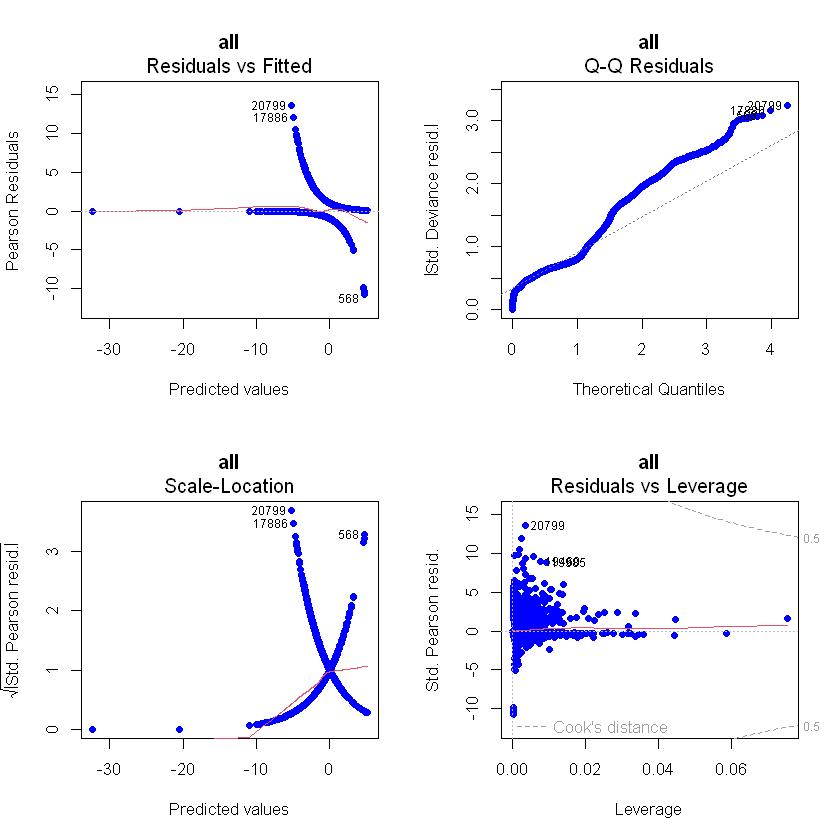

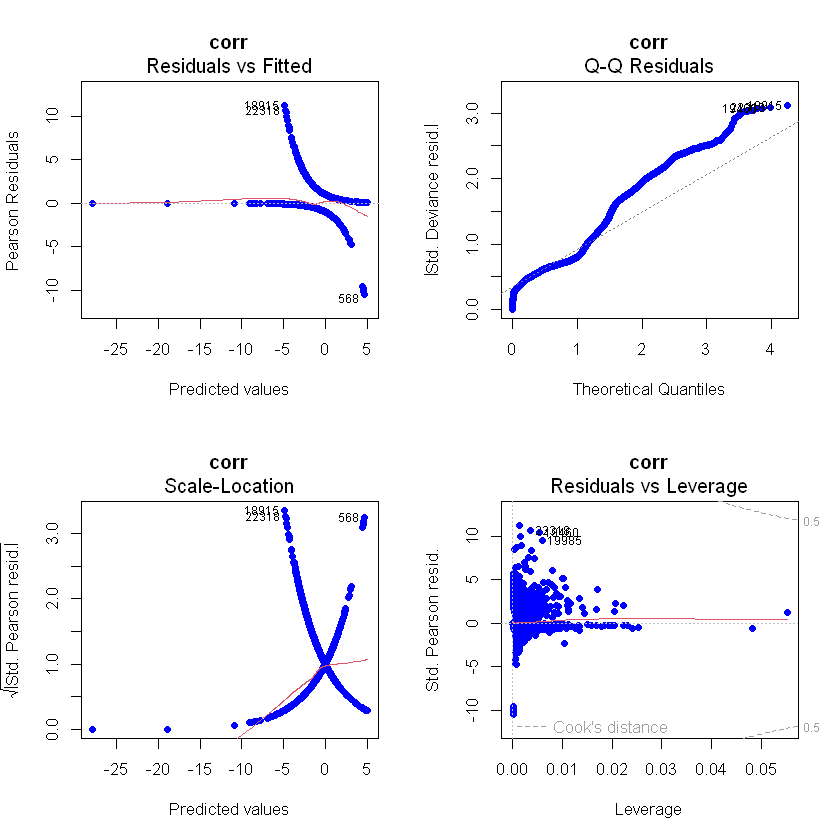

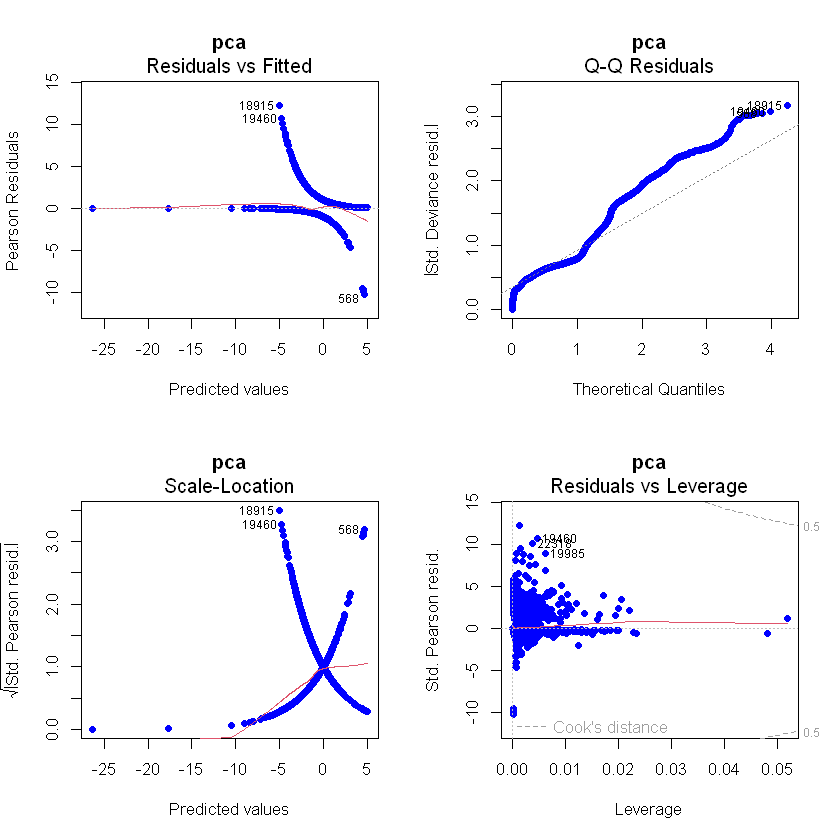

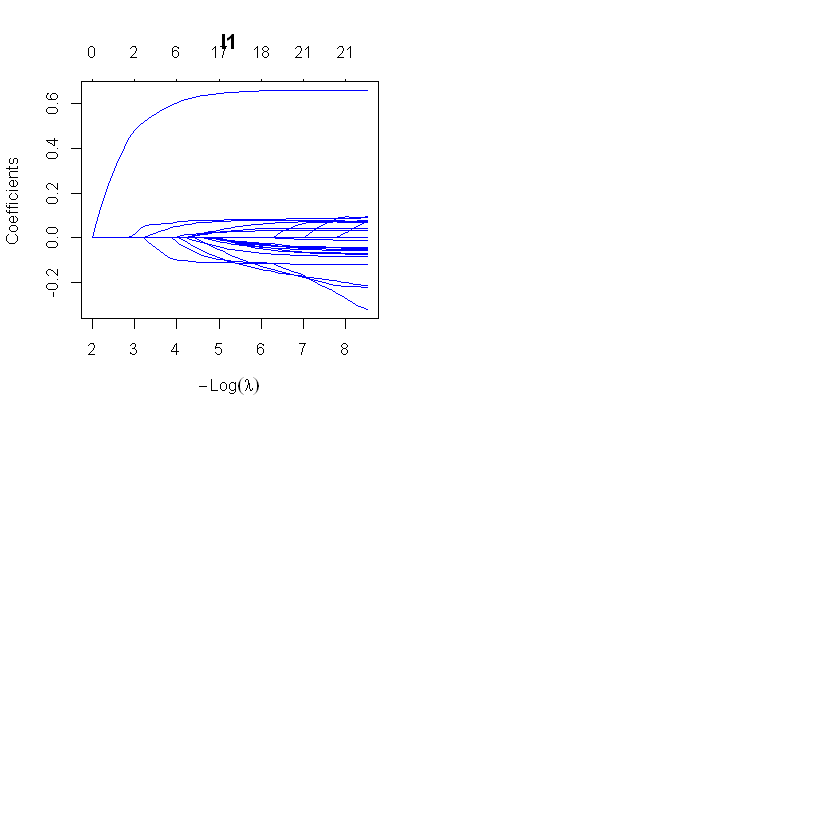

In [269]:
purrr::walk2(
  fits_tbl$fit,
  fits_tbl$wflow_id,
  ~ {
    modelo <- get_model(.x)

    par(mfrow = c(2, 2))
    plot(
      modelo,
      pch = 19,
      col = "blue",
      main = .y
    )
  }
)